<a href="https://colab.research.google.com/github/eniompw/microgpt/blob/main/microgpt_fast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MicroGPT — PyTorch (Colab T4 GPU)

The most atomic way to train and run inference for a GPT in pure PyTorch.
Based on [@karpathy](https://github.com/karpathy)'s microgpt.

> **Runtime:** Go to **Runtime → Change runtime type → T4 GPU** before running.

## 1. GPU Setup and Library Imports

In [28]:
import os
import random
import json
import torch
import torch.nn.functional as F

# Reproducibility
random.seed(42)
torch.manual_seed(42)

# Device setup — will use T4 GPU on Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Dataset Download and Preparation

In [29]:
import pandas as pd

if not os.path.exists('input.txt'):
    print("Downloading TinyStories dataset from HuggingFace...")
    df = pd.read_parquet("hf://datasets/karpathy/tinystories-gpt4-clean/tinystories_gpt4_clean.parquet")
    stories = df['text'].iloc[20000:25000].tolist()  # 5000 stories
    with open('input.txt', 'w') as f:
        for story in stories:
            f.write(json.dumps(story) + '\n')
    print(f"Saved {len(stories)} stories to input.txt")
else:
    print("input.txt already exists, skipping download.")

docs = [json.loads(line) for line in open('input.txt') if line.strip()]
random.shuffle(docs)
print(f"num docs: {len(docs)}")
print(f"sample doc: {docs[0][:120]}...")

input.txt already exists, skipping download.
num docs: 5000
sample doc: Ben and Lily were playing in the farm with their new friend, Mira the mule. Mira was very strong and gentle, and she lik...


## 3. Tokenizer Setup

In [30]:
# Character-level vocabulary — all 74 chars present in the dataset
uchars = sorted('\n !"$\',-.' + '0123456789:;?' + 'ABCDEFGHIJKLMNOPQRSTUVWXYZ' + 'abcdefghijklmnopqrstuvwxyz')
BOS = len(uchars)          # special Beginning-of-Sequence token id
vocab_size = len(uchars) + 1
print(f"vocab size: {vocab_size}")
print(f"BOS token id: {BOS}")

# Encode / decode helpers
encode = lambda s: [uchars.index(ch) for ch in s]
decode = lambda ids: ''.join(uchars[i] for i in ids)

# Sanity check
sample_text = "Once upon a time"
encoded = encode(sample_text)
decoded = decode(encoded)
print(f"encode('{sample_text}') → {encoded}")
print(f"decode(...)           → '{decoded}'")

vocab size: 75
BOS token id: 74
encode('Once upon a time') → [36, 61, 50, 52, 1, 68, 63, 62, 61, 1, 48, 1, 67, 56, 60, 52]
decode(...)           → 'Once upon a time'


## 4. Model Hyperparameters and Parameter Initialization

In [31]:
import math

# ── Hyperparameters ───────────────────────────────────────────────────────────
n_layer    = 6       # transformer depth
n_embd     = 256     # embedding dim
block_size = 256     # context window
n_head     = 8       # attention heads
head_dim   = n_embd // n_head
batch_size = 64      # sequences per gradient step

# ── Weight init ──────────────────────────────────────────────────────────────
matrix = lambda nout, nin: torch.randn(nout, nin, device=device) * 0.02

state_dict = {
    'wte': matrix(vocab_size, n_embd),   # token embeddings (weight-tied to lm_head)
}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)

params = list(state_dict.values())
for p in params:
    p.requires_grad_(True)

total_params = sum(p.numel() for p in params)
print(f"num params: {total_params:,}")
print(f"tokens per iter: {batch_size * block_size:,}")

num params: 4,737,792
tokens per iter: 16,384


## 5. Model Architecture Definition

Llama-style transformer: RMSNorm, RoPE, flash attention, weight tying.


In [32]:
def rmsnorm(x):
    """RMSNorm along last dim — works for any shape."""
    return x * (x.pow(2).mean(-1, keepdim=True) + 1e-5).rsqrt()

# ── RoPE (Rotary Position Embeddings) ────────────────────────────────────────
freqs = 1.0 / (10000.0 ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
freqs = torch.outer(torch.arange(block_size, device=device).float(), freqs)
rope_cos, rope_sin = freqs.cos(), freqs.sin()   # (block_size, head_dim//2)

def apply_rope(x, cos, sin):
    """x: (B,T,H,D) or (H,D). cos/sin: (T,D//2) or (D//2,)"""
    d = x.dtype
    x = x.float().unflatten(-1, (-1, 2))
    x_r, x_i = x[..., 0], x[..., 1]
    if x.dim() == 5:  # batched
        cos = cos.view(1, -1, 1, cos.shape[-1])
        sin = sin.view(1, -1, 1, sin.shape[-1])
    return torch.stack([x_r*cos - x_i*sin, x_r*sin + x_i*cos], -1).flatten(-2).to(d)

# ── Batched forward (for training) ───────────────────────────────────────────
def gpt_train(tokens):
    """tokens: (B, T) long -> logits: (B, T, vocab_size)"""
    bsz, seqlen = tokens.shape
    x = rmsnorm(F.embedding(tokens, state_dict['wte']))
    cos, sin = rope_cos[:seqlen], rope_sin[:seqlen]
    for li in range(n_layer):
        r = x
        x = rmsnorm(x)
        q = F.linear(x, state_dict[f'layer{li}.attn_wq']).view(bsz, seqlen, n_head, head_dim)
        k = F.linear(x, state_dict[f'layer{li}.attn_wk']).view(bsz, seqlen, n_head, head_dim)
        v = F.linear(x, state_dict[f'layer{li}.attn_wv']).view(bsz, seqlen, n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        x = F.scaled_dot_product_attention(
            q.transpose(1,2), k.transpose(1,2), v.transpose(1,2), is_causal=True
        ).transpose(1,2).contiguous().view(bsz, seqlen, -1)
        x = F.linear(x, state_dict[f'layer{li}.attn_wo']) + r
        r = x
        x = rmsnorm(x)
        x = F.silu(F.linear(x, state_dict[f'layer{li}.mlp_fc1']))
        x = F.linear(x, state_dict[f'layer{li}.mlp_fc2']) + r
    return F.linear(rmsnorm(x), state_dict['wte'])   # weight-tied lm_head

gpt_train = torch.compile(gpt_train)  # fuse GPU kernels for ~2x speedup

# ── Single-token forward (for inference with KV cache) ───────────────────────
def gpt(token_id, pos_id, keys, values):
    x = rmsnorm(state_dict['wte'][token_id])
    cos, sin = rope_cos[pos_id], rope_sin[pos_id]
    for li in range(n_layer):
        r = x
        x = rmsnorm(x)
        q = F.linear(x, state_dict[f'layer{li}.attn_wq']).view(n_head, head_dim)
        k = F.linear(x, state_dict[f'layer{li}.attn_wk']).view(n_head, head_dim)
        v = F.linear(x, state_dict[f'layer{li}.attn_wv']).view(n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        keys[li].append(k); values[li].append(v)
        x_attn = []
        for h in range(n_head):
            k_h = torch.stack([ki[h] for ki in keys[li]])
            v_h = torch.stack([vi[h] for vi in values[li]])
            x_attn.append(F.softmax(k_h @ q[h] / head_dim**0.5, dim=0) @ v_h)
        x = F.linear(torch.cat(x_attn), state_dict[f'layer{li}.attn_wo']) + r
        r = x
        x = rmsnorm(x)
        x = F.silu(F.linear(x, state_dict[f'layer{li}.mlp_fc1']))
        x = F.linear(x, state_dict[f'layer{li}.mlp_fc2']) + r
    return F.linear(rmsnorm(x), state_dict['wte'])

print("Model functions defined.")

Model functions defined.


## 6. Training Loop

Total tokens: 4,051,708
step    0/2000 | loss 5.2302 | lr 0.00e+00 | 4.3s
step  100/2000 | loss 2.2199 | lr 5.00e-04 | 13.4s
step  200/2000 | loss 1.5270 | lr 1.00e-03 | 18.8s
step  300/2000 | loss 1.2804 | lr 9.92e-04 | 24.2s
step  400/2000 | loss 1.1434 | lr 9.70e-04 | 29.7s
step  500/2000 | loss 1.0507 | lr 9.33e-04 | 35.1s
step  600/2000 | loss 0.9986 | lr 8.83e-04 | 40.5s
step  700/2000 | loss 0.9599 | lr 8.21e-04 | 45.9s
step  800/2000 | loss 0.9226 | lr 7.50e-04 | 51.2s
step  900/2000 | loss 0.9268 | lr 6.71e-04 | 56.5s
step 1000/2000 | loss 0.8690 | lr 5.87e-04 | 61.8s
step 1100/2000 | loss 0.8509 | lr 5.00e-04 | 67.1s
step 1200/2000 | loss 0.8226 | lr 4.13e-04 | 72.4s
step 1300/2000 | loss 0.8178 | lr 3.29e-04 | 77.9s
step 1400/2000 | loss 0.8270 | lr 2.50e-04 | 83.1s
step 1500/2000 | loss 0.7876 | lr 1.79e-04 | 88.4s
step 1600/2000 | loss 0.7654 | lr 1.17e-04 | 93.7s
step 1700/2000 | loss 0.7551 | lr 6.70e-05 | 99.0s
step 1800/2000 | loss 0.7795 | lr 3.02e-05 | 104.4s
step 19

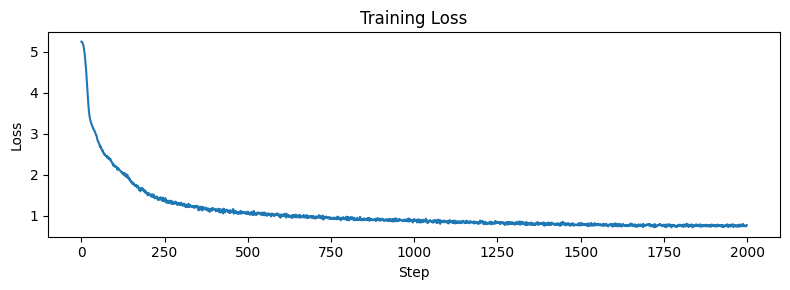

In [33]:
import time
import matplotlib.pyplot as plt

# ── Prepare token stream ─────────────────────────────────────────────────────
all_tokens = []
for doc in docs:
    all_tokens.extend([BOS] + encode(doc))
all_tokens.append(BOS)
all_tokens = torch.tensor(all_tokens, dtype=torch.long, device=device)
print(f"Total tokens: {len(all_tokens):,}")

# ── Optimizer: AdamW ─────────────────────────────────────────────────────────
num_steps     = 2000
warmup_steps  = 200
learning_rate = 1e-3

optimizer = torch.optim.AdamW(params, lr=learning_rate, betas=(0.9, 0.95), eps=1e-10)

# Mixed precision (float16 on T4)
scaler = torch.amp.GradScaler('cuda')

# ── Training loop ────────────────────────────────────────────────────────────
loss_history = []
t0 = time.time()

for step in range(num_steps + 1):
    # Cosine learning rate schedule with warmup
    if step < warmup_steps:
        lr_t = learning_rate * step / warmup_steps
    else:
        progress = (step - warmup_steps) / (num_steps - warmup_steps)
        lr_t = learning_rate * 0.5 * (1 + math.cos(math.pi * progress))
    for g in optimizer.param_groups:
        g['lr'] = lr_t

    if step % 100 == 0:
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
            ix = torch.randint(0, len(all_tokens) - block_size - 1, (batch_size,))
            xb = torch.stack([all_tokens[i:i+block_size] for i in ix])
            yb = torch.stack([all_tokens[i+1:i+block_size+1] for i in ix])
            el = F.cross_entropy(gpt_train(xb).view(-1, vocab_size), yb.view(-1)).item()
        print(f"step {step:4d}/{num_steps} | loss {el:.4f} | lr {lr_t:.2e} | {time.time()-t0:.1f}s")

    if step >= num_steps:
        break

    optimizer.zero_grad()
    ix = torch.randint(0, len(all_tokens) - block_size - 1, (batch_size,))
    xb = torch.stack([all_tokens[i:i+block_size] for i in ix])
    yb = torch.stack([all_tokens[i+1:i+block_size+1] for i in ix])
    with torch.amp.autocast('cuda', dtype=torch.float16):
        loss = F.cross_entropy(gpt_train(xb).view(-1, vocab_size), yb.view(-1))
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(params, 1.0)
    scaler.step(optimizer)
    scaler.update()
    loss_history.append(loss.item())

print(f"\nDone in {time.time()-t0:.1f}s")
plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.tight_layout(); plt.show()

## 7. Inference and Text Generation

In [34]:
temperature = 0.8   # (0, 1] — lower = more focused, higher = more random
num_samples = 5
max_new_tokens = 200  # generate up to this many tokens per sample

print("--- inference (hallucinated stories) ---\n")
for sample_idx in range(num_samples):
    keys   = [[] for _ in range(n_layer)]
    values = [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    with torch.no_grad():
        for pos_id in range(max_new_tokens):
            pos = min(pos_id, block_size - 1)
            logits = gpt(token_id, pos, keys, values)
            probs  = F.softmax(logits[:vocab_size] / temperature, dim=-1)
            token_id = torch.multinomial(probs, 1).item()
            if token_id == BOS:
                break
            sample.append(uchars[token_id])
    print(f"sample {sample_idx+1}:\n{''.join(sample)}\n")


--- inference (hallucinated stories) ---

sample 1:
Once there was a cogant. The sun was shining and kind wet. He wanted to design a bag.
Suddenly, a big box of hide on a hug. He would be went to the house, and showed his mum why his oats and did not k

sample 2:
Once upon a time, there was a girl named Mia. Mia was sad and a big red hat, but she kept walking about the owl. Mia wanted to get a swim and the cat.
Mom went away for drops and saw her mom and said,

sample 3:
One day, a little dog named Max went to the park. He saw something in the park. He was a small leg from an adventure. Lily liked to catch the biggest and touch they needed to wake up.
One day, Max saw

sample 4:
One sunny day, a little girl named Mia went to Tom and saw a big piece of cookies. It was wet and took it to his net. She would hear juice because she could paint back inside. She is scared of the dir

sample 5:
One day, a little girl named Mia went to the park, there was a little girl named Lily. She was very 